In [2]:
library(Seurat)
library(DESeq2)
library(dplyr)
library(purrr)
library(tibble)
library(tidyverse)
library(ggplot2)
library(forcats)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:SeuratObject’:

    intersect


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following obj

1. pseudobulk counts per sample × cell_type × condition
2. run DESeq2 separately for each cell type: PLA vs platelet_free
3. get DE table: cell_type, gene, log2FoldChange, stat, pvalue, padj
4. get ligand-receptor resource from LIANA/OmniPath
5. join: ligand DE in source cell type, receptor DE in target cell type
6. rank interactions

In [2]:
data_path <- "/nfs/home/students/i.kaciran/FoPra_PLAs/data/datasets/"
# "gated_ImmuneAging.rds", "gated_heart_processed.rds", "gated_sepsis_processed.rds", "gated_vaccine_processed.rds", "gated_our_dataset_processed.rds"
#file_name <- "gated_ImmuneAging.rds"
#file_name <- "gated_heart_processed.rds" 
file_name <- "gated_sepsis_processed.rds" 
#file_name <- "gated_vaccine_processed.rds" 
#file_name <- "gated_our_dataset_processed.rds" 

file_path <- file.path(data_path, file_name)

if (file_name == "gated_ImmuneAging.rds"){
    dataset_type <- "immune_aging"
} else if (file_name == "gated_heart_processed.rds"){
    dataset_type <- "heart"
} else if (file_name == "gated_sepsis_processed.rds"){
    dataset_type <- "sepsis"
} else if (file_name == "gated_vaccine_processed.rds"){
    dataset_type <- "vaccine"
} else if (file_name == "gated_our_dataset_processed.rds"){
    dataset_type <- "our_data"
}

In [3]:
seurat_obj <- readRDS(paste0(data_path, file_name))
metadata <- seurat_obj@meta.data
clean_name <- str_remove(file_name, "\\.rds$")

In [4]:
sample_col    <- "sample"       # technical / sample-level replicate
donor_col     <- "donor_id"     # biological donor
celltype_col  <- "celltype"     # broad cell type
celltype_full <- "celltype_full" # more detailed cell type
condition_col <- "pla_status"   # PLA vs platelet-free
lineage_col   <- "lineage"

In [5]:
table(seurat_obj$pla_status, useNA = "ifany")
table(seurat_obj$celltype, useNA = "ifany")
table(seurat_obj$celltype_full, useNA = "ifany")
table(seurat_obj$sample, useNA = "ifany")
table(seurat_obj$donor_id, useNA = "ifany")
table(seurat_obj$lineage, useNA = "ifany")


          PLA platelet-free 
        39405        245638 


                          B cells                        CD4 T cells  
                             21276                              50729 
                      CD8 T cells                Classical monocytes  
                             26904                              15248 
                               DCs                               DCs  
                              2810                               2770 
                   Early NK cells             Intermediate monocytes  
                              3807                               1292 
                    Late NK cells                          Monocytes  
                              7364                               7056 
                       Neutrophils                      NK / DC mixed 
                              4210                               1563 
                          NK cells                          NK cells  
                             23037                                  3 
     


                                  DCs                              NK cells 
                                 2810                                 23037 
                   NK cells, DC cells                                   R11 
                                 1563                                 12701 
                                  R13                              Singlets 
                                 1510                                  1990 
                          neutrophils   non B cell/non T cell/ non monocyte 
                                 4210                                  3525 
                             non cDCs                           non-B cells 
                                 5074                                    57 
              non-T cell/ non NK cell                                  pDCs 
                                90792                                   158 
                      pla CD8 T cells                           pla b cells


GSM8571042_Abd-S111  GSM8571043_Abd-S23  GSM8571044_Abd-S42  GSM8571045_Abd-S45 
               6531                6019                5919                5430 
 GSM8571046_Abd-S49  GSM8571047_Abd-S51  GSM8571048_Abd-S55  GSM8571049_Abd-S66 
               5805                7938                6850                6799 
 GSM8571050_Abd-S67  GSM8571051_Abd-S75  GSM8571052_Abd-S80  GSM8571053_Abd-S81 
               6702                6545                6530                7522 
  GSM8571054_Abd-S9  GSM8571055_Abd-S91     GSM8571056_HC01     GSM8571057_HC05 
               7446                8803                8774                7394 
    GSM8571058_HC13     GSM8571059_IC08     GSM8571060_IC09     GSM8571061_IC10 
               7173                5653                7750                8704 
    GSM8571062_IC19     GSM8571063_IC23  GSM8571064_Res-S10 GSM8571065_Res-S100 
              10231                9597                7296                6831 
GSM8571066_Res-S118 GSM8571


Abd-S111  Abd-S23  Abd-S42  Abd-S45  Abd-S49  Abd-S51  Abd-S55  Abd-S66 
    6531     6019     5919     5430     5805     7938     6850     6799 
 Abd-S67  Abd-S75  Abd-S80  Abd-S81   Abd-S9  Abd-S91     HC01     HC05 
    6702     6545     6530     7522     7446     8803     8774     7394 
    HC13     IC08     IC09     IC10     IC19     IC23  Res-S10 Res-S100 
    7173     5653     7750     8704    10231     9597     7296     6831 
Res-S118 Res-S146 Res-S149 Res-S164 Res-S166 Res-S170 Res-S183  Res-S19 
    7055     8071     7317     8452     5351     6862     6757     6304 
 Res-S22  Res-S40  Res-S41  Res-S70 Uri-S134 Uri-S157  Uri-S85  Uri-S88 
    9188     7273     5967     4989     7393     7365     5863     6594 


        DCs    NK cells  Unassigned neutrophils CD8 T cells     B cells 
       5738       34211      117212        4210       26904       21276 
CD4 T cells   Monocytes        <NA> 
      50729       24471         292 

In [6]:
seurat_obj$pla_status[is.na(seurat_obj$pla_status)] <- "platelet-free"

In [7]:
table(seurat_obj$pla_status, useNA = "ifany")


          PLA platelet-free 
        39405        245638 

In [19]:
saveRDS(seurat_obj, file_path)

In [ ]:
table(seurat_obj$pla_status, seurat_obj$lineage)

               
                   DCs NK cells Unassigned neutrophils CD8 T cells B cells
  PLA             2298     2443          0           0        7504     488
  platelet-free   3440    31768     117212        4210       19400   20788
               
                CD4 T cells Monocytes
  PLA                  5680     20992
  platelet-free       45049      3479

In [9]:
table(seurat_obj$sample, seurat_obj$donor_id)

                     
                      Abd-S111 Abd-S23 Abd-S42 Abd-S45 Abd-S49 Abd-S51 Abd-S55
  GSM8571042_Abd-S111     6531       0       0       0       0       0       0
  GSM8571043_Abd-S23         0    6019       0       0       0       0       0
  GSM8571044_Abd-S42         0       0    5919       0       0       0       0
  GSM8571045_Abd-S45         0       0       0    5430       0       0       0
  GSM8571046_Abd-S49         0       0       0       0    5805       0       0
  GSM8571047_Abd-S51         0       0       0       0       0    7938       0
  GSM8571048_Abd-S55         0       0       0       0       0       0    6850
  GSM8571049_Abd-S66         0       0       0       0       0       0       0
  GSM8571050_Abd-S67         0       0       0       0       0       0       0
  GSM8571051_Abd-S75         0       0       0       0       0       0       0
  GSM8571052_Abd-S80         0       0       0       0       0       0       0
  GSM8571053_Abd-S81         0

In [ ]:
seurat_obj$sample_clean <- gsub("_", "-", seurat_obj$sample) # seurats aggregateexpression changes underscores to dashes

# create one group label for every cell
# eg GSM8571042-Abd-S111|B cells|PLA
# seurat then adds togehter all of these cells
seurat_obj$pb_group <- paste(
  seurat_obj$sample_clean,
  seurat_obj$lineage,
  seurat_obj$pla_status,
  sep = "|"
)

# for deseq2 we need one metadata row per pseudobulk group
pb_meta <- seurat_obj@meta.data %>%
  as.data.frame() %>%
  tibble::rownames_to_column("cell_id") %>%
  dplyr::distinct(pb_group, sample, sample_clean, donor_id, lineage, pla_status) %>%
  dplyr::rename(
    sample_id = sample_clean,
    original_sample = sample,
    condition = pla_status
  )
# each psedubulk sample then has these cols: 
# pb_group, sample_id, original_sample, donor_id, lineage, condition

# actual pseudobulking
pb_counts <- AggregateExpression(
  seurat_obj,
  assays = "RNA",
  slot = "counts",
  group.by = "pb_group",
  return.seurat = FALSE
)$RNA
# so we get pseudobulk group + gene count

head(colnames(pb_counts))
head(pb_meta$pb_group)

all(colnames(pb_counts) %in% pb_meta$pb_group)
all(pb_meta$pb_group %in% colnames(pb_counts))

[1] "GSM8571042-Abd-S111|B cells|PLA"              
[2] "GSM8571042-Abd-S111|B cells|platelet-free"    
[3] "GSM8571042-Abd-S111|CD4 T cells|PLA"          
[4] "GSM8571042-Abd-S111|CD4 T cells|platelet-free"
[5] "GSM8571042-Abd-S111|CD8 T cells|PLA"          
[6] "GSM8571042-Abd-S111|CD8 T cells|platelet-free"

[1] "GSM8571042-Abd-S111|Unassigned|platelet-free" 
[2] "GSM8571042-Abd-S111|neutrophils|platelet-free"
[3] "GSM8571042-Abd-S111|B cells|platelet-free"    
[4] "GSM8571042-Abd-S111|CD4 T cells|platelet-free"
[5] "GSM8571042-Abd-S111|CD8 T cells|PLA"          
[6] "GSM8571042-Abd-S111|CD4 T cells|PLA"

[1] TRUE

[1] TRUE

In [ ]:
# order the same (matters for deseq2)
pb_meta <- pb_meta %>%
  dplyr::filter(pb_group %in% colnames(pb_counts)) %>%
  dplyr::arrange(match(pb_group, colnames(pb_counts))) %>%
  as.data.frame()

rownames(pb_meta) <- pb_meta$pb_group

all(rownames(pb_meta) == colnames(pb_counts))

[1] TRUE

In [20]:
pb_meta %>%
  dplyr::count(lineage, condition) %>%
  tidyr::pivot_wider(
    names_from = condition,
    values_from = n,
    values_fill = 0
  )

lineage,PLA,platelet-free
<fct>,<int>,<int>
DCs,40,40
NK cells,40,40
Unassigned,0,40
neutrophils,0,40
CD8 T cells,40,40
B cells,40,40
CD4 T cells,40,40
Monocytes,40,40
NA,0,38


In [24]:
# Make sure condition is clean
pb_meta$condition <- factor(pb_meta$condition)
pb_meta$condition <- relevel(pb_meta$condition, ref = "platelet-free")

run_deseq_lineage <- function(lin) {
  
  message("Running DESeq2 for lineage: ", lin)
  
  # subset metadata for this lineage
  meta_lin <- pb_meta %>%
    filter(lineage == lin) %>%
    as.data.frame()
  
  # skip missing/empty lineages
  if (nrow(meta_lin) == 0) {
    message("Skipping ", lin, ": no pseudobulk samples.")
    return(NULL)
  }
  
  # skip if only one condition exists
  if (length(unique(meta_lin$condition)) < 2) {
    message("Skipping ", lin, ": only one condition present.")
    return(NULL)
  }
  
  # subset counts
  counts_lin <- pb_counts[, rownames(meta_lin), drop = FALSE]
  
  # keep genes with some counts
  keep_genes <- rowSums(counts_lin) >= 10
  counts_lin <- counts_lin[keep_genes, , drop = FALSE]
  
  # make sure metadata order matches counts
  stopifnot(all(rownames(meta_lin) == colnames(counts_lin)))
  
  # use paired design if possible
  design_formula <- ~ sample_id + condition
  
  dds <- DESeqDataSetFromMatrix(
    countData = round(counts_lin),
    colData = meta_lin,
    design = design_formula
  )
  
  dds <- DESeq(dds)
  
  res <- results(
    dds,
    contrast = c("condition", "PLA", "platelet-free")
  )
  
  as.data.frame(res) %>%
    rownames_to_column("gene") %>%
    mutate(lineage = lin) %>%
    arrange(padj)
}

In [25]:
all_lineages <- unique(pb_meta$lineage)

de_tbl <- map_dfr(all_lineages, run_deseq_lineage)

Running DESeq2 for lineage: B cells

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  lett

In [26]:
head(de_tbl)
table(de_tbl$lineage)

,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,lineage
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,CEBPD,113.36427,5.208117,0.1734133,30.03298,3.642683e-198,5.585690e-194,B cells
2,FYB1,47.45176,4.575300,0.1555367,29.41621,3.407290e-190,2.612370e-186,B cells
3,ANXA1,65.70769,4.523377,0.1592514,28.40401,1.804414e-177,9.222960e-174,B cells
4,CTSD,53.91952,4.625621,0.1740158,26.58161,1.107581e-155,4.245912e-152,B cells
5,TYMP,108.65729,3.131982,0.1187419,26.37638,2.558021e-153,7.844939e-150,B cells
6,CLU,56.67975,5.906927,0.2268871,26.03466,2.007197e-149,5.129727e-146,B cells



        DCs    NK cells  Unassigned neutrophils CD8 T cells     B cells 
      15174       18363           0           0       16679       16980 
CD4 T cells   Monocytes 
      18233       17189 

In [ ]:
out_dir <- "/nfs/home/students/i.kaciran/FoPra_PLAs/results/differential_ccs/liana_plus"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

saveRDS(
  de_tbl,
  file.path(out_dir, "pseudobulk_deseq2_by_lineage.rds")
)

write.csv(
  de_tbl,
  file.path(out_dir, "pseudobulk_deseq2_by_lineage.csv"),
  row.names = FALSE
)

In [28]:
de_tbl %>%
  filter(!is.na(padj), padj < 0.05) %>%
  count(lineage, direction = ifelse(log2FoldChange > 0, "PLA_up", "platelet_free_up"))

lineage,direction,n
<fct>,<chr>,<int>
DCs,PLA_up,149
DCs,platelet_free_up,295
NK cells,PLA_up,1592
NK cells,platelet_free_up,625
CD8 T cells,PLA_up,1382
CD8 T cells,platelet_free_up,1108
B cells,PLA_up,4353
B cells,platelet_free_up,1415
CD4 T cells,PLA_up,3770


In [29]:
de_tbl %>%
  filter(!is.na(padj), padj < 0.05) %>%
  count(lineage, direction = ifelse(log2FoldChange > 0, "PLA_up", "platelet_free_up"))

lineage,direction,n
<fct>,<chr>,<int>
DCs,PLA_up,149
DCs,platelet_free_up,295
NK cells,PLA_up,1592
NK cells,platelet_free_up,625
CD8 T cells,PLA_up,1382
CD8 T cells,platelet_free_up,1108
B cells,PLA_up,4353
B cells,platelet_free_up,1415
CD4 T cells,PLA_up,3770


In [31]:
de_tbl %>%
  filter(!is.na(padj), padj < 0.05) %>%
  count(lineage, direction = ifelse(log2FoldChange > 0, "PLA_up", "platelet_free_up"))

de_tbl %>%
  filter(!is.na(padj), padj < 0.05, abs(log2FoldChange) > 1) %>%
  count(lineage, direction = ifelse(log2FoldChange > 0, "PLA_up", "platelet_free_up"))

lineage,direction,n
<fct>,<chr>,<int>
DCs,PLA_up,149
DCs,platelet_free_up,295
NK cells,PLA_up,1592
NK cells,platelet_free_up,625
CD8 T cells,PLA_up,1382
CD8 T cells,platelet_free_up,1108
B cells,PLA_up,4353
B cells,platelet_free_up,1415
CD4 T cells,PLA_up,3770


lineage,direction,n
<fct>,<chr>,<int>
DCs,PLA_up,3
DCs,platelet_free_up,119
NK cells,PLA_up,999
NK cells,platelet_free_up,200
CD8 T cells,PLA_up,242
CD8 T cells,platelet_free_up,121
B cells,PLA_up,3032
B cells,platelet_free_up,352
CD4 T cells,PLA_up,1396


de_tbl tells us for each lineage and each gene, whether that gene is higher in pla or platelet-free; high log2fold change = high in PLA, low log2fold change = high in platelet-free; eg PTPRCAP is lower in PLA-associated DC pseudobulks and higher in platelet-free DC pseudobulks

In [32]:
de_tbl %>%
  filter(!is.na(padj)) %>%
  group_by(lineage) %>%
  slice_min(padj, n = 10) %>%
  ungroup() %>%
  select(lineage, gene, log2FoldChange, stat, pvalue, padj)

lineage,gene,log2FoldChange,stat,pvalue,padj
<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
DCs,PTPRCAP,-3.2341273,-9.059245,1.313570e-19,1.413533e-15
DCs,GZMM,-3.0723525,-8.905132,5.332261e-19,2.869023e-15
DCs,CD7,-2.3946463,-8.391085,4.816741e-17,1.727765e-13
DCs,LINC00861,-2.5858191,-7.995530,1.290179e-15,3.470903e-12
DCs,LY9,-2.5943171,-7.907020,2.636227e-15,5.673687e-12
DCs,LBH,-2.1006823,-7.416671,1.201008e-13,2.154008e-10
DCs,IL32,-3.1565896,-7.308398,2.703456e-13,4.155985e-10
DCs,ZAP70,-2.4086278,-7.266891,3.678565e-13,4.948130e-10
DCs,PCED1B-AS1,-1.5278964,-6.984998,2.848607e-12,3.405985e-09


In [35]:
liana::show_resources()

lr_resource <- liana::select_resource("Consensus")[[1]]

glimpse(lr_resource)

[1] "Default"          "Consensus"        "Baccin2019"       "CellCall"        
 [5] "CellChatDB"       "Cellinker"        "CellPhoneDB"      "CellTalkDB"      
 [9] "connectomeDB2020" "EMBRACE"          "Guide2Pharma"     "HPMR"            
[13] "ICELLNET"         "iTALK"            "Kirouac2010"      "LRdb"            
[17] "Ramilowski2015"   "OmniPath"         "MouseConsensus"

Rows: 4,701
Columns: 10
$ source                    <chr> "O00182", "O00182", "O00182", "O00182", "O00…
$ target                    <chr> "P08575", "P08581", "P16070", "Q07954", "Q08…
$ source_genesymbol         <chr> "LGALS9", "LGALS9", "LGALS9", "LGALS9", "LGA…
$ target_genesymbol         <chr> "PTPRC", "MET", "CD44", "LRP1", "CD47", "PTP…
$ category_intercell_source <chr> "cell_surface_ligand", "cell_surface_ligand"…
$ database_intercell_source <chr> "CellPhoneDB", "CellPhoneDB", "CellPhoneDB",…
$ category_intercell_target <chr> "receptor", "receptor", "receptor", "recepto…
$ database_intercell_target <chr> "connectomeDB2020;CellChatDB;CellTalkDB", "c…
$ sources                   <chr> "CellChatDB;Cellinker", "CellPhoneDB;InnateD…
$ references                <chr> "CellChatDB:30120235;Cellinker:30120235", ""…


In [36]:
lr_pairs <- lr_resource %>%
  dplyr::transmute(
    ligand = source_genesymbol,
    receptor = target_genesymbol,
    lr_source_db = sources,
    lr_reference = references
  ) %>%
  dplyr::distinct(ligand, receptor, .keep_all = TRUE) %>%
  dplyr::filter(!is.na(ligand), !is.na(receptor))

In [37]:
lr_pairs

ligand,receptor,lr_source_db,lr_reference
<chr>,<chr>,<chr>,<chr>
LGALS9,PTPRC,CellChatDB;Cellinker,CellChatDB:30120235;Cellinker:30120235
LGALS9,MET,CellPhoneDB;InnateDB-All_CellPhoneDB,
LGALS9,CD44,CellChatDB;CellPhoneDB;CellTalkDB;Cellinker;InnateDB;InnateDB_CellPhoneDB;connectomeDB2020,CellChatDB:25065622;CellTalkDB:32103204;Cellinker:25065622;InnateDB:20206131;connectomeDB2020:25065622
LGALS9,LRP1,CellPhoneDB;InnateDB-All_CellPhoneDB,
LGALS9,CD47,CellPhoneDB;CellTalkDB;InnateDB-All_CellPhoneDB,CellTalkDB:32103204
LGALS9,PTPRK,CellPhoneDB;InnateDB-All_CellPhoneDB,
LGALS9,COLEC12,CellPhoneDB;InnateDB-All_CellPhoneDB,
LGALS9,HAVCR2,CellChatDB;CellPhoneDB;CellPhoneDB_Cellinker;CellTalkDB;Cellinker;ICELLNET;InnateDB;LRdb;connectomeDB2020;iTALK,CellChatDB:27192565;CellPhoneDB:27192565;CellTalkDB:27192565;Cellinker:27192565;ICELLNET:16286920;ICELLNET:27192565;InnateDB:23967307;LRdb:22437870;connectomeDB2020:27192565
LGALS9,MRC2,CellPhoneDB;CellTalkDB;InnateDB-All_CellPhoneDB,CellTalkDB:32103204


In [40]:
ligand_de <- de_tbl %>%
  dplyr::select(lineage, gene, log2FoldChange, stat, pvalue, padj) %>%
  dplyr::rename(
    source = lineage,
    ligand = gene,
    ligand_log2FC = log2FoldChange,
    ligand_stat = stat,
    ligand_pvalue = pvalue,
    ligand_padj = padj
  )

receptor_de <- de_tbl %>%
  dplyr::select(lineage, gene, log2FoldChange, stat, pvalue, padj) %>%
  dplyr::rename(
    target = lineage,
    receptor = gene,
    receptor_log2FC = log2FoldChange,
    receptor_stat = stat,
    receptor_pvalue = pvalue,
    receptor_padj = padj
  )

get lineages that were actually tested in deseq2

In [ ]:
tested_lineages <- de_tbl %>%
  dplyr::filter(!is.na(lineage)) %>%
  dplyr::distinct(lineage) %>%
  dplyr::pull(lineage)

lineage_pairs <- tidyr::expand_grid( # creates all combinations
  source = tested_lineages,
  target = tested_lineages
)

In [46]:
lineage_pairs

source,target
<fct>,<fct>
B cells,B cells
B cells,CD4 T cells
B cells,CD8 T cells
B cells,DCs
B cells,Monocytes
B cells,NK cells
CD4 T cells,B cells
CD4 T cells,CD4 T cells
CD4 T cells,CD8 T cells


In [4]:
diff_lr <- lineage_pairs %>%
  tidyr::crossing(lr_pairs) %>% # combine every source-target pair with every ligand-receptor pair
  dplyr::left_join(ligand_de, by = c("source", "ligand")) %>% # for this source cell type, find the DE result of ligand gene
  dplyr::left_join(receptor_de, by = c("target", "receptor"))  # for this target cell type, find DE result of receptor gene

ERROR: Error: object 'lineage_pairs' not found


DE result of [gene] in [lineage]<br>
DE result of [ligand] in [source]<br>
DE result of [receptor] in [target]<br>

In [43]:
diff_lr

source,target,ligand,receptor,lr_source_db,lr_reference,ligand_log2FC,ligand_stat,ligand_pvalue,ligand_padj,receptor_log2FC,receptor_stat,receptor_pvalue,receptor_padj
<fct>,<fct>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DCs,DCs,A2M,LRP1,AlzPathway;Baccin2019;CellTalkDB;EMBRACE;Fantom5_LRdb;HPMR_LRdb;HPMR_talklr;HPRD;HPRD_LRdb;HPRD_talklr;LRdb;Ramilowski2015;Ramilowski2015_Baccin2019;STRING_talklr;Wang;connectomeDB2020;iTALK;talklr,AlzPathway:19026743;Baccin2019:10652313;Baccin2019:12194978;Baccin2019:1702392;CellTalkDB:10652313;HPRD:10652313;HPRD:12194978;LRdb:10652313;connectomeDB2020:10652313;connectomeDB2020:12194978;connectomeDB2020:1702392,0.73605603,0.25241499,0.8007203,NA,0.023256129,0.53432226,0.5931185970,0.871813854
DCs,DCs,AANAT,MTNR1A,Baccin2019;CellTalkDB;Fantom5_LRdb;HPMR;HPMR_LRdb;HPMR_talklr;LRdb;Ramilowski2015;Ramilowski2015_Baccin2019;Wang;connectomeDB2020;iTALK;talklr,Baccin2019:12943195;CellTalkDB:12943195;HPMR:12943195;LRdb:12943195;connectomeDB2020:12943195,NA,NA,NA,NA,NA,NA,NA,NA
DCs,DCs,AANAT,MTNR1B,Baccin2019;CellTalkDB;Fantom5_LRdb;HPMR_LRdb;HPMR_talklr;LRdb;Ramilowski2015;Ramilowski2015_Baccin2019;Wang;connectomeDB2020;iTALK;talklr,Baccin2019:12943195;CellTalkDB:12943195;LRdb:12943195;connectomeDB2020:12943195,NA,NA,NA,NA,NA,NA,NA,NA
DCs,DCs,ACE,AGTR2,Baccin2019;CellTalkDB;Fantom5_LRdb;HPRD;HPRD_LRdb;HPRD_talklr;LRdb;Ramilowski2015;Ramilowski2015_Baccin2019;iTALK;talklr,Baccin2019:11459796;HPRD:11459796;LRdb:11459796,0.56746678,0.23376997,0.8151636,NA,NA,NA,NA,NA
DCs,DCs,ACE,BDKRB2,Baccin2019;CellTalkDB;EMBRACE;Fantom5_LRdb;HPRD;HPRD_LRdb;HPRD_talklr;LRdb;Lit-BM-17;Ramilowski2015;Ramilowski2015_Baccin2019;connectomeDB2020;iTALK;talklr,Baccin2019:10748135;CellTalkDB:10748135;HPRD:10748135;LRdb:10748135;Lit-BM-17:17077303;connectomeDB2020:10748135,0.56746678,0.23376997,0.8151636,NA,NA,NA,NA,NA
DCs,DCs,ACTR2,ADRB2,CellTalkDB;LRdb;Reactome_LRdb,CellTalkDB:32196115,-0.01445614,-0.37209379,0.7098230,0.9170725,-0.326495274,-2.07509579,0.0379776580,0.285031035
DCs,DCs,ACTR2,LDLR,CellTalkDB;LRdb;Reactome_LRdb,CellTalkDB:32196115,-0.01445614,-0.37209379,0.7098230,0.9170725,-0.094700727,-0.60184197,0.5472793379,0.852898120
DCs,DCs,ACTR2,LRP2,CellTalkDB;LRdb;Reactome_LRdb,CellTalkDB:32196115,-0.01445614,-0.37209379,0.7098230,0.9170725,NA,NA,NA,NA
DCs,DCs,ADA,DPP4,CellTalkDB;DIP;HPRD;LRdb,CellTalkDB:15213224;DIP:8568233;HPRD:11772392;LRdb:21738897,-0.27549802,-2.00451050,0.0450154,0.3115349,-0.902193411,-0.86372099,0.3877411788,NA


In [ ]:
diff_lr <- diff_lr %>%
  dplyr::mutate(
    ligand_sig = !is.na(ligand_padj) & ligand_padj < 0.05,
    receptor_sig = !is.na(receptor_padj) & receptor_padj < 0.05,
    either_sig = ligand_sig | receptor_sig,
    both_sig = ligand_sig & receptor_sig,

    ligand_strong = ligand_sig & abs(ligand_log2FC) > 1,
    receptor_strong = receptor_sig & abs(receptor_log2FC) > 1,
    either_strong = ligand_strong | receptor_strong,
    both_strong = ligand_strong & receptor_strong,

    both_up_PLA = ligand_log2FC > 0 & receptor_log2FC > 0,
    both_up_platelet_free = ligand_log2FC < 0 & receptor_log2FC < 0,

    direction = dplyr::case_when(
      both_up_PLA ~ "PLA-up ligand and receptor",
      both_up_platelet_free ~ "platelet-free-up ligand and receptor",
      ligand_log2FC > 0 & receptor_log2FC < 0 ~ "PLA-up ligand, platelet-free-up receptor",
      ligand_log2FC < 0 & receptor_log2FC > 0 ~ "platelet-free-up ligand, PLA-up receptor",
      TRUE ~ "mixed/unclear"
    ),

    interaction_score = dplyr::coalesce(abs(ligand_stat), 0) + # rank interactions by how strongly the ligand and receptor are differentially expressed
      dplyr::coalesce(abs(receptor_stat), 0),

    signed_interaction_score = dplyr::coalesce(ligand_stat, 0) +
      dplyr::coalesce(receptor_stat, 0)
  )

In [45]:
dim(diff_lr)

diff_lr %>%
  dplyr::arrange(dplyr::desc(interaction_score)) %>%
  dplyr::select(
    source, target, ligand, receptor,
    ligand_log2FC, receptor_log2FC,
    ligand_padj, receptor_padj,
    direction, interaction_score, signed_interaction_score
  ) %>%
  head(30)

[1] 169236     27

source,target,ligand,receptor,ligand_log2FC,receptor_log2FC,ligand_padj,receptor_padj,direction,interaction_score,signed_interaction_score
<fct>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
B cells,B cells,ANXA1,FPR1,4.523377,5.337227,9.222960e-174,4.212338e-101,PLA-up ligand and receptor,50.01640,50.01640
B cells,B cells,ANXA1,DYSF,4.523377,5.784693,9.222960e-174,4.861283e-86,PLA-up ligand and receptor,48.32466,48.32466
B cells,B cells,S100A9,CD36,5.956396,5.901012,2.581808e-127,3.006126e-114,PLA-up ligand and receptor,47.27058,47.27058
B cells,B cells,S100A12,CD36,5.860321,5.901012,1.017345e-119,3.006126e-114,PLA-up ligand and receptor,46.52667,46.52667
B cells,B cells,S100A8,CD36,5.956025,5.901012,2.066559e-114,3.006126e-114,PLA-up ligand and receptor,45.99466,45.99466
CD4 T cells,B cells,PF4,LRP1,5.030686,5.641776,2.810539e-88,1.525297e-134,PLA-up ligand and receptor,45.27593,45.27593
B cells,B cells,PF4,LRP1,5.744563,5.641776,2.306621e-85,1.525297e-134,PLA-up ligand and receptor,44.81810,44.81810
B cells,B cells,PSAP,LRP1,2.031001,5.641776,5.625639e-85,1.525297e-134,PLA-up ligand and receptor,44.77209,44.77209
B cells,B cells,S100A9,TLR4,5.956396,4.394524,2.581808e-127,5.072287e-87,PLA-up ligand and receptor,44.31800,44.31800


In [54]:
out_dir <- "/nfs/home/students/i.kaciran/FoPra_PLAs/results/differential_ccs"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

saveRDS(
  diff_lr,
  file.path(out_dir, "diff_lr_all_lineages_liana_consensus.rds")
)

write.csv(
  diff_lr,
  file.path(out_dir, "diff_lr_all_lineages_liana_consensus.csv"),
  row.names = FALSE
)

In [67]:
diff_lr_plot <- diff_lr %>%
  mutate(
    pair_padj = pmax(ligand_padj, receptor_padj, na.rm = TRUE),
    pair_significance = -log10(pair_padj),
    
    interaction_direction = case_when(
      both_sig & ligand_log2FC > 0 & receptor_log2FC > 0 ~ "PLA-up",
      both_sig & ligand_log2FC < 0 & receptor_log2FC < 0 ~ "platelet-free-up",
      both_sig ~ "discordant",
      TRUE ~ "not both significant"
    )
  )

PLA-up:
    ligand higher in PLA
    receptor higher in PLA
    both significant

platelet-free-up:
    ligand higher in platelet-free
    receptor higher in platelet-free
    both significant

discordant:
    both significant, but ligand and receptor move in opposite directions

not both significant:
    not enough evidence on both sides

In [68]:
summary_net <- diff_lr_plot %>%
  filter(interaction_direction %in% c("PLA-up", "platelet-free-up")) %>%
  group_by(source, target, interaction_direction) %>%
  summarise(
    n = n(),
    .groups = "drop"
  ) %>%
  pivot_wider(
    names_from = interaction_direction,
    values_from = n,
    values_fill = 0
  ) %>%
  mutate(
    net_PLA_minus_platelet_free = `PLA-up` - `platelet-free-up`,
    total_directional = `PLA-up` + `platelet-free-up`
  )

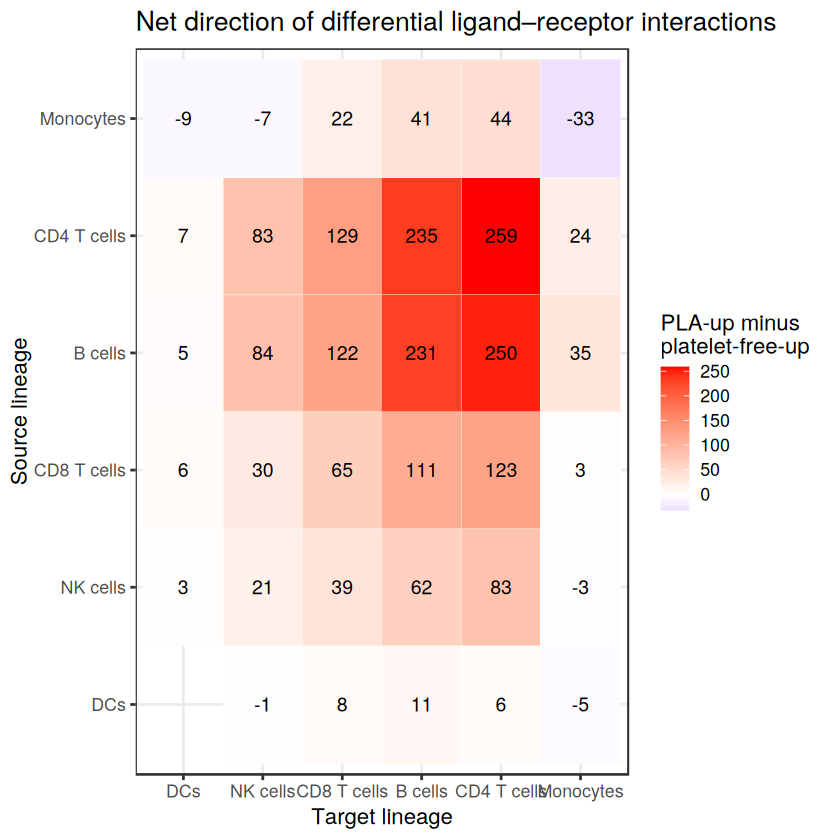

In [69]:
p_net <- ggplot(summary_net, aes(
  x = target,
  y = source,
  fill = net_PLA_minus_platelet_free
)) +
  geom_tile(color = "white") +
  geom_text(aes(label = net_PLA_minus_platelet_free), size = 4) +
  scale_fill_gradient2(
    low = "blue",
    mid = "white",
    high = "red",
    midpoint = 0
  ) +
  theme_bw(base_size = 13) +
  labs(
    x = "Target lineage",
    y = "Source lineage",
    fill = "PLA-up minus\nplatelet-free-up",
    title = "Net direction of differential ligand–receptor interactions"
  )

p_net

red = more PLA-associated LR pairs<br>
blue = more platelet-free-associated LR pairs<br>
white = balanced / little net direction<br>
number = PLA-up count minus platelet-free-up count<br>

In [70]:
summary_total <- diff_lr_plot %>%
  filter(interaction_direction %in% c("PLA-up", "platelet-free-up", "discordant")) %>%
  group_by(source, target) %>%
  summarise(
    n_differential = n(),
    .groups = "drop"
  )

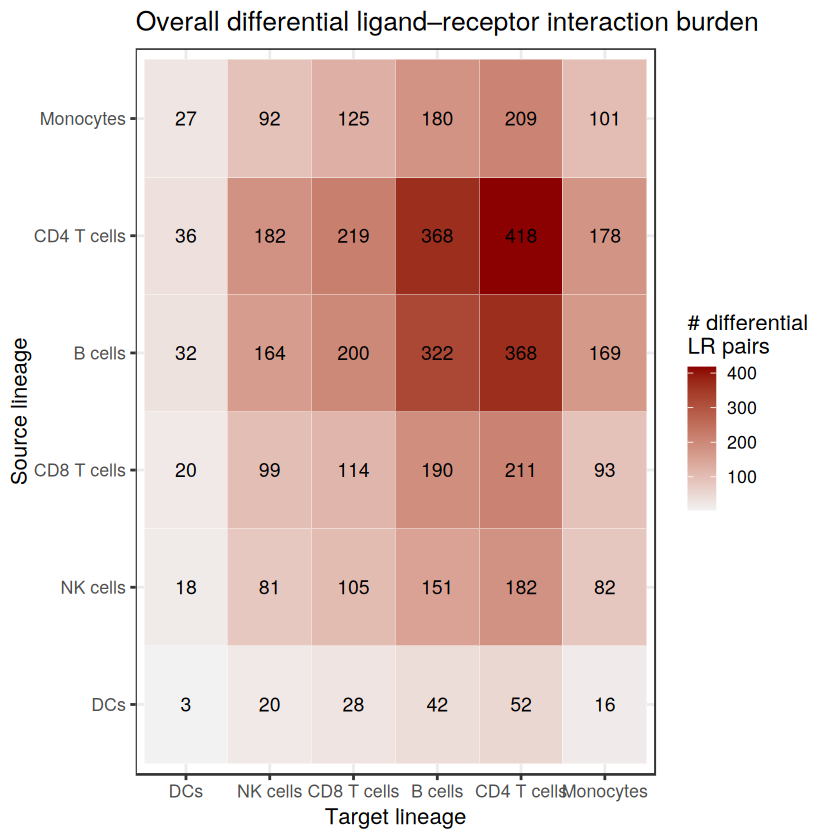

In [71]:
p_total <- ggplot(summary_total, aes(
  x = target,
  y = source,
  fill = n_differential
)) +
  geom_tile(color = "white") +
  geom_text(aes(label = n_differential), size = 4) +
  scale_fill_gradient(low = "grey95", high = "darkred") +
  theme_bw(base_size = 13) +
  labs(
    x = "Target lineage",
    y = "Source lineage",
    fill = "# differential\nLR pairs",
    title = "Overall differential ligand–receptor interaction burden"
  )

p_total

In [72]:
summary_direction <- diff_lr_plot %>%
  filter(interaction_direction != "not both significant") %>%
  count(source, target, interaction_direction) %>%
  mutate(
    source_target = paste0(source, " → ", target)
  )

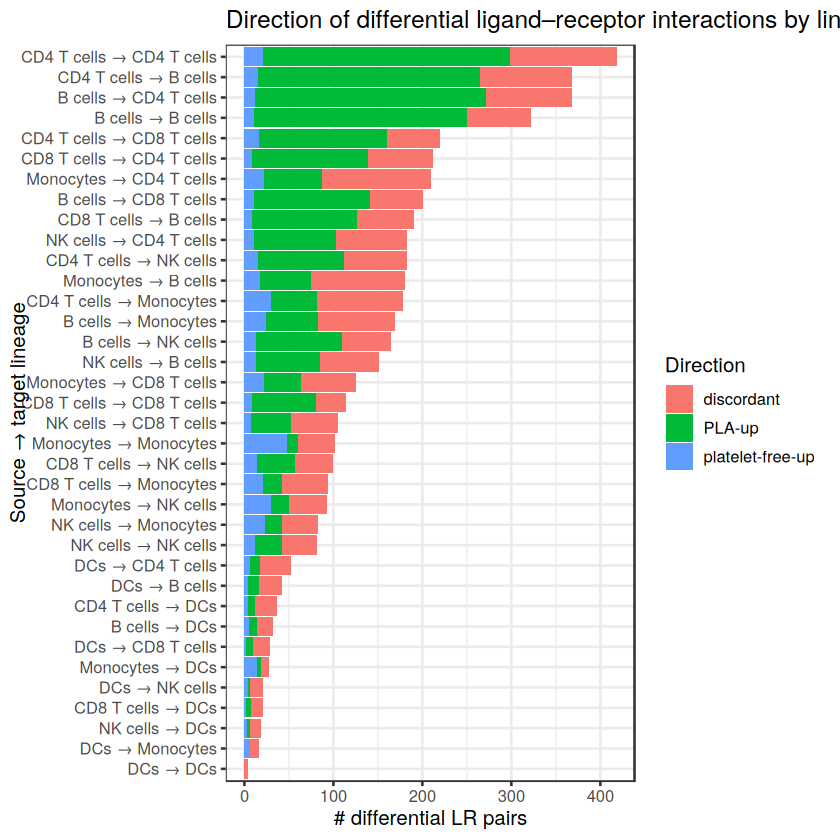

In [73]:
p_direction_bar <- ggplot(summary_direction, aes(
  x = fct_reorder(source_target, n, .fun = sum),
  y = n,
  fill = interaction_direction
)) +
  geom_col() +
  coord_flip() +
  theme_bw(base_size = 12) +
  labs(
    x = "Source → target lineage",
    y = "# differential LR pairs",
    fill = "Direction",
    title = "Direction of differential ligand–receptor interactions by lineage pair"
  )

p_direction_bar

In [74]:
global_direction <- diff_lr_plot %>%
  count(interaction_direction)

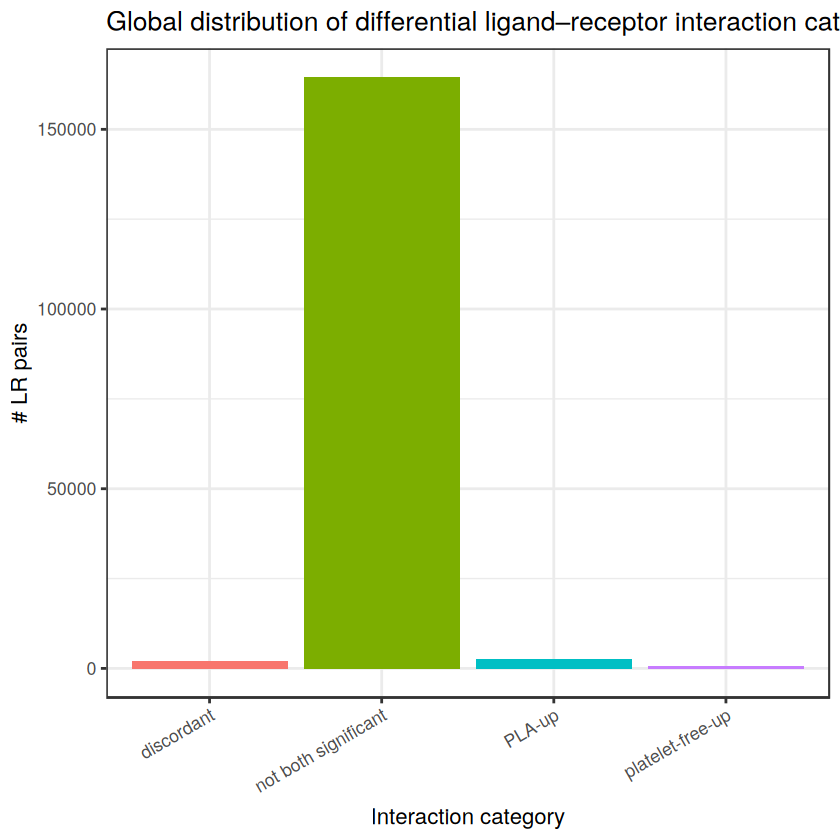

In [75]:
p_global <- ggplot(global_direction, aes(
  x = interaction_direction,
  y = n,
  fill = interaction_direction
)) +
  geom_col() +
  theme_bw(base_size = 13) +
  theme(
    axis.text.x = element_text(angle = 30, hjust = 1),
    legend.position = "none"
  ) +
  labs(
    x = "Interaction category",
    y = "# LR pairs",
    title = "Global distribution of differential ligand–receptor interaction categories"
  )

p_global

In [89]:
top_lr_recurrent <- diff_lr_plot %>%
  filter(interaction_direction %in% c("PLA-up", "platelet-free-up")) %>%
  mutate(
    interaction = paste0(ligand, " → ", receptor)
  ) %>%
  group_by(interaction, interaction_direction) %>%
  summarise(
    n_source_target = n(),
    mean_abs_score = mean(abs(signed_interaction_score), na.rm = TRUE),
    mean_signed_score = mean(signed_interaction_score, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(n_source_target), desc(mean_abs_score)) %>%
  slice_head(n = 25) %>%
  mutate(
    interaction = fct_reorder(interaction, n_source_target)
  )

p_recurrent_count <- ggplot(top_lr_recurrent, aes(
  x = n_source_target,
  y = interaction,
  fill = interaction_direction
)) +
  geom_col() +
  theme_bw(base_size = 12) +
  labs(
    x = "# source–target lineage pairs",
    y = "Ligand → receptor",
    fill = "Direction",
    title = "Most recurrent differential ligand–receptor pairs"
  )

In [90]:
# Choose top recurrent LR pairs, not top by score
top_lr_pairs <- diff_lr_plot %>%
  filter(interaction_direction %in% c("PLA-up", "platelet-free-up")) %>%
  mutate(interaction = paste0(ligand, " → ", receptor)) %>%
  count(interaction, sort = TRUE) %>%
  slice_head(n = 25) %>%
  pull(interaction)

dot_df <- diff_lr_plot %>%
  filter(interaction_direction %in% c("PLA-up", "platelet-free-up")) %>%
  mutate(interaction = paste0(ligand, " → ", receptor)) %>%
  filter(interaction %in% top_lr_pairs) %>%
  group_by(interaction, interaction_direction) %>%
  summarise(
    n_source_target = n(),
    median_abs_ligand_log2FC = median(abs(ligand_log2FC), na.rm = TRUE),
    median_abs_receptor_log2FC = median(abs(receptor_log2FC), na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    median_abs_effect = (median_abs_ligand_log2FC + median_abs_receptor_log2FC) / 2,
    interaction = fct_reorder(interaction, n_source_target, .fun = sum)
  )

p_recurrent_dotplot <- ggplot(dot_df, aes(
  x = interaction_direction,
  y = interaction,
  size = n_source_target,
  color = median_abs_effect
)) +
  geom_point(alpha = 0.85) +
  scale_size_continuous(name = "# source–target pairs") +
  scale_color_gradient(low = "grey80", high = "red", name = "Median abs. log2FC") +
  theme_bw(base_size = 12) +
  labs(
    x = "Direction",
    y = "Ligand → receptor",
    title = "Most recurrent differential ligand–receptor pairs"
  )

In [91]:
plot_df <- diff_lr %>%
  filter(both_sig) %>%
  arrange(desc(abs(signed_interaction_score))) %>%
  slice_head(n = top_n) %>%
  mutate(
    interaction = paste0(ligand, " → ", receptor),
    source_target = paste0(source, " → ", target),
    interaction = fct_reorder(interaction, signed_interaction_score)
  )

p_top_dotplot <- ggplot(plot_df, aes(
  x = source_target,
  y = interaction,
  color = signed_interaction_score,
  size = interaction_score
)) +
  geom_point(alpha = 0.85) +
  scale_color_gradient2(
    low = "blue",
    mid = "white",
    high = "red",
    midpoint = 0
  ) +
  theme_bw(base_size = 13) +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)
  ) +
  labs(
    x = "Source → target lineage",
    y = "Ligand → receptor",
    color = "Signed interaction score",
    size = "Interaction score",
    title = "Top differential ligand–receptor interactions (both sig)"
  )

In [6]:
diff_lr <- readRDS(
  "/nfs/home/students/i.kaciran/FoPra_PLAs/results/differential_ccs/liana_plus/diff_lr_all_lineages_liana_consensus.rds"
)

plot_df_balanced <- diff_lr %>%
  filter(both_sig) %>%
  mutate(
    interaction = paste0(ligand, " → ", receptor),
    source_target = paste0(source, " → ", target)
  ) %>%
  group_by(source_target) %>%
  slice_max(order_by = interaction_score, n = 3, with_ties = FALSE) %>%
  ungroup() %>%
  mutate(
    interaction = fct_reorder(interaction, signed_interaction_score)
  )

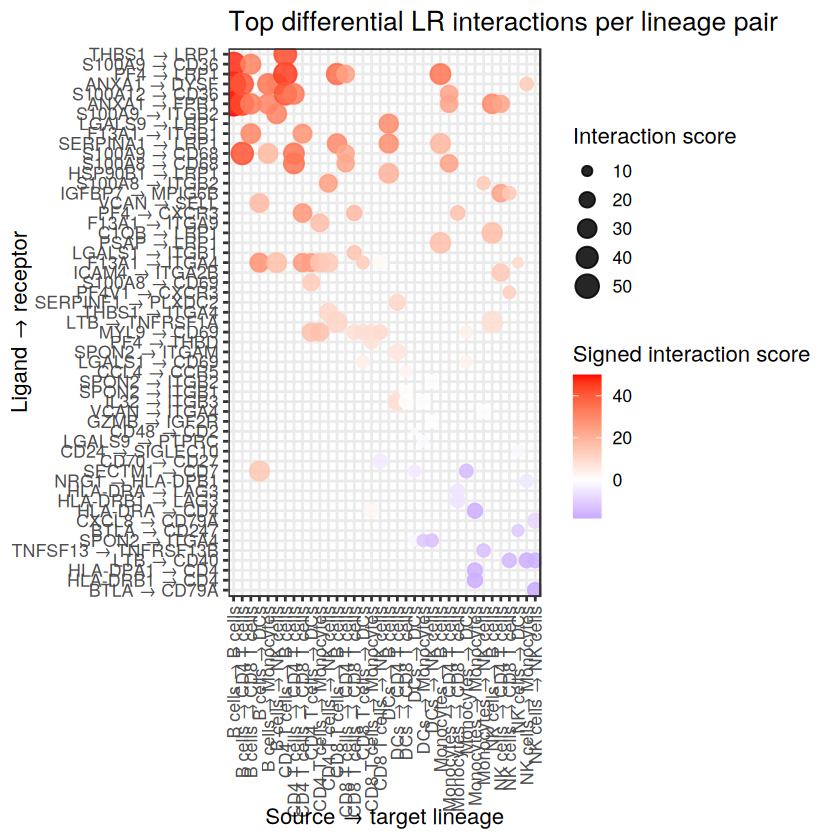

In [ ]:
p_top_balanced <- ggplot(plot_df_balanced, aes(
  x = source_target,
  y = interaction,
  color = signed_interaction_score,
  size = interaction_score
)) +
  geom_point(alpha = 0.85) +
  scale_color_gradient2(
    low = "blue",
    mid = "white",
    high = "red",
    midpoint = 0
  ) +
  theme_bw(base_size = 13) +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)
  ) +
  labs(
    x = "Source → target lineage",
    y = "Ligand → receptor",
    color = "Signed interaction score",
    size = "Interaction score",
    title = "Top differential LR interactions per lineage pair"
  )

p_top_balanced



In [12]:
ggsave(
  file.path(out_dir, "diff_lr_top_interactions_both_sig_dotplot_all_celltypes.png"),
  p_top_balanced,
  width = 14,
  height = 11
)


In [ ]:
out_dir <- "/nfs/home/students/i.kaciran/FoPra_PLAs/results/differential_ccs/plots/liana_plus"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

ggsave(
  file.path(out_dir, "diff_lr_net_direction_heatmap.png"),
  p_net,
  width = 8,
  height = 6
)

ggsave(
  file.path(out_dir, "diff_lr_total_burden_heatmap.png"),
  p_total,
  width = 8,
  height = 6
)

ggsave(
  file.path(out_dir, "diff_lr_direction_stacked_bar.png"),
  p_direction_bar,
  width = 10,
  height = 9
)

ggsave(
  file.path(out_dir, "diff_lr_global_direction_counts.png"),
  p_global,
  width = 7,
  height = 5
)

ggsave(
  file.path(out_dir, "diff_lr_recurrent_lr_pairs_barplot.png"),
  p_recurrent_count,
  width = 9,
  height = 7
)

ggsave(
  file.path(out_dir, "diff_lr_recurrent_lr_pairs_dotplot.png"),
  p_recurrent_dotplot,
  width = 8,
  height = 7
)

ggsave(
  file.path(out_dir, "diff_lr_top_interactions_both_sig_dotplot.png"),
  p_top_dotplot,
  width = 11,
  height = 8
)
